# Infinite Series, Power Series


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython import display
from IPython.display import Markdown
from scipy.special import factorial
from scipy import stats
from scipy import constants

# Below are some adjustments:
# from IPython.display import HTML
# HTML('<style>img[alt="skan"] { filter: invert(100%); }</style>')
# plt.style.use('dark_background')


## Problems, Section 2
***In the following problems, find the limit of the given sequence as $n \to \infty$.***


### 2.6 
$$\LARGE \lim_{n \to \infty} \frac{n^n}{n!}$$

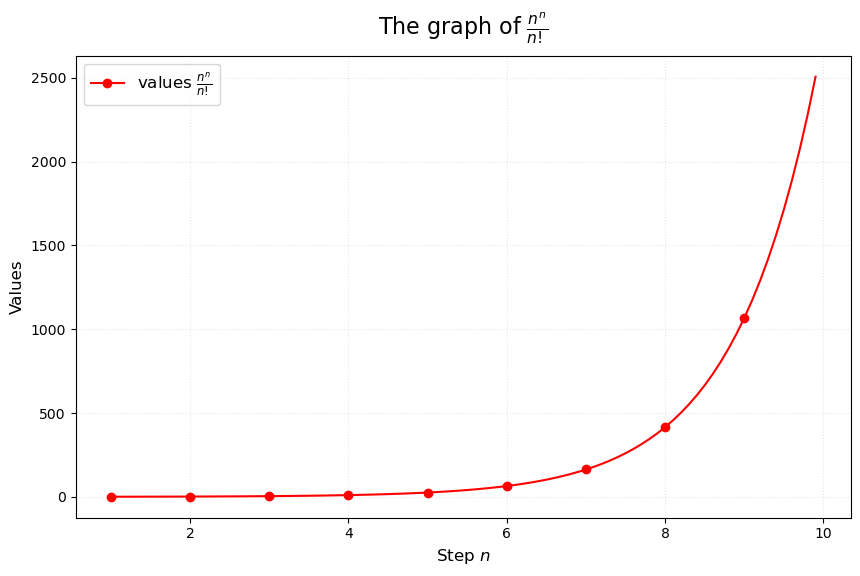

|   Step $n$ |   Numerator $n^n$ |   denominator $n!$ |   Value $\frac{n^n}{n!}$ |
|-----------:|------------------:|-------------------:|-------------------------:|
|          1 |       1           |                  1 |                   1      |
|          2 |       4           |                  2 |                   2      |
|          3 |      27           |                  6 |                   4.5    |
|          4 |     256           |                 24 |                  10.6667 |
|          5 |    3125           |                120 |                  26.0417 |
|          6 |   46656           |                720 |                  64.8    |
|          7 |  823543           |               5040 |                 163.401  |
|          8 |       1.67772e+07 |              40320 |                 416.102  |
|          9 |       3.8742e+08  |             362880 |                1067.63   |

In [9]:
# 1. Simulation setup
# We keep the range small (1 to 10) because n^n grows insanely fast.
n_max: float = 10.0
step: float = 0.1
start: float = 1.0
n_values = np.arange(start, n_max, step)
custom_mk = 10

numerators = n_values**n_values
denominators = factorial(n_values)
results = numerators / denominators

# 3. Plotting the chart
plt.figure(figsize=(10, 6))

# Draw the main line
plt.plot(n_values, results, color='red', marker='o', markevery=custom_mk, label=r'values $\frac{n^n}{n!}$')

# You may ask "why is this code excluded?"
# Let's have a look at the table of Values below
# It's reasonable not to include numerator and denominator because of the rapid growth of those values
#plt.plot(n_values, numerators, color='blue', linestyle='-', marker='s', markevery=5, label=r'numerator $n^n$')
#plt.plot(n_values, denominators, color='green', linestyle='--', marker='^', markevery=5, label=r'denominator $n!$')

# Aesthetics and labels
plt.title(r'The graph of $\frac{n^n}{n!}$', fontsize=16, pad=15)
plt.xlabel('Step $n$', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.3)
plt.legend(fontsize=12)

# Render the plot
plt.show()

table_data = {
    r"Step $n$": n_values,
    r"Numerator $n^n$": numerators,
    r"denominator $n!$": denominators,
    r"Value $\frac{n^n}{n!}$": results
}
df = pd.DataFrame(table_data)
df_sliced = df.iloc[::10]
Markdown(df_sliced.to_markdown(index=False))

![2.6](./assets/2.6.png)

### 2.7
$$\LARGE\lim_{n \to \infty}\left((1+n^2)^\frac{1}{\ln n}\right)$$

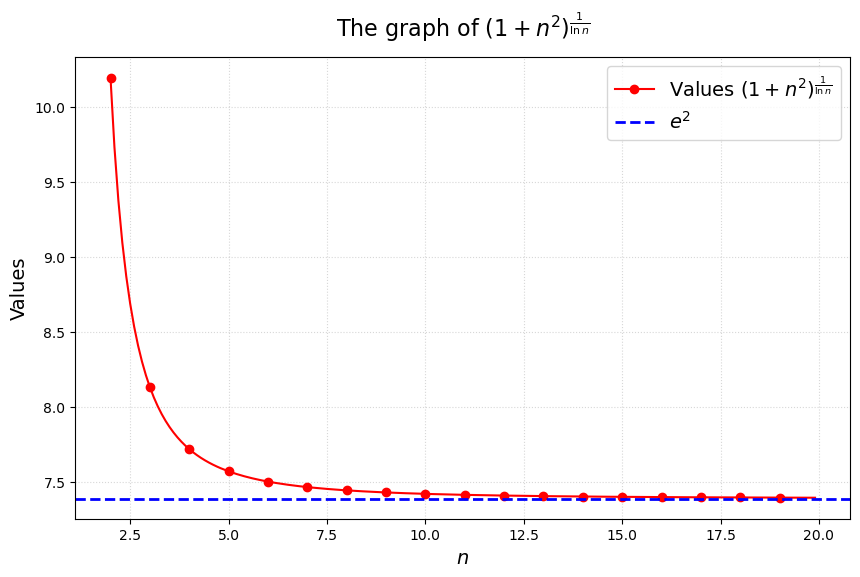

|   Step $n$ |   Base $1 + n^2$ |   Power $\frac{1}{\ln n}$ |   Values $(1+n^2)^\frac{1}{\ln n}$ |
|-----------:|-----------------:|--------------------------:|-----------------------------------:|
|          2 |      5           |                  1.4427   |                            10.1953 |
|          4 |    257           |                  0.721348 |                             7.7194 |
|          6 |  46657           |                  0.558111 |                             7.5029 |
|          8 |      1.67772e+07 |                  0.480898 |                             7.4444 |
|         10 |      1e+10       |                  0.434294 |                             7.4211 |
|         12 |      8.9161e+12  |                  0.40243  |                             7.4097 |
|         14 |      1.1112e+16  |                  0.378923 |                             7.4033 |
|         16 |      1.84467e+19 |                  0.360674 |                             7.3995 |
|         18 |      3.93464e+22 |                  0.345976 |                             7.3969 |

In [10]:
def compute():
    n_max = 20
    n_start = 2.0 
    n_step = 0.1
    n_values = np.arange(n_start, n_max, n_step)
    results = (1 + n_values**2)**(1 / np.log(n_values))
    powers = 1 / np.log(n_values)
    bases = 1 + n_values**n_values

    plt.figure(figsize=(10,6))

    plt.plot(n_values, results, color='red', linestyle="-", marker='o', markevery=10, label=r'Values $(1+n^2)^\frac{1}{\ln n}$')

    euler_value = np.exp(2)

    plt.axhline(y=euler_value, color='blue', linestyle='--',linewidth=2, label=r'$e^2$')
    plt.title(r"The graph of $(1+n^2)^\frac{1}{\ln n}$", fontsize=16, pad=15)
    plt.xlabel('$n$', fontsize=14)
    plt.ylabel('Values', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(fontsize=14, loc='upper right')

    plt.show()

    table_data = {
        r"Step $n$": n_values,
        r"Base $1 + n^2$": bases,
        r"Power $\frac{1}{\ln n}$": powers,
        r"Values $(1+n^2)^\frac{1}{\ln n}$": np.round(results, 4)
    }

    df = pd.DataFrame(table_data)
    df_sliced = df.iloc[::20]
    return Markdown(df_sliced.to_markdown(index=False))

compute()

![2.7](./assets/2.9.png)

### 2.8
$$\lim_{n \to \infty}\frac{(n!)^2}{(2n)!}$$

In [11]:
def compute():
    max_n = 1024
    n_values = list(range(2, max_n+1))
    results = []

    for n in n_values:
        numerator = math.factorial(n)**2
        denominator = math.factorial(2*n)
        value = numerator / denominator
        results.append(value)

    for i in [2,4,8,16,32,64,128,256,512, 1023]:
        print(f"For {i} the value is approximately {results[i-1]:.4f}")

  
    
compute()

For 2 the value is approximately 0.0500
For 4 the value is approximately 0.0040
For 8 the value is approximately 0.0000
For 16 the value is approximately 0.0000
For 32 the value is approximately 0.0000
For 64 the value is approximately 0.0000
For 128 the value is approximately 0.0000
For 256 the value is approximately 0.0000
For 512 the value is approximately 0.0000
For 1023 the value is approximately 0.0000


![2.8](./assets/2.8.png)

### 2.9
$$\lim_{n \to \infty} n\sin \left ( \frac{1}{n} \right)$$

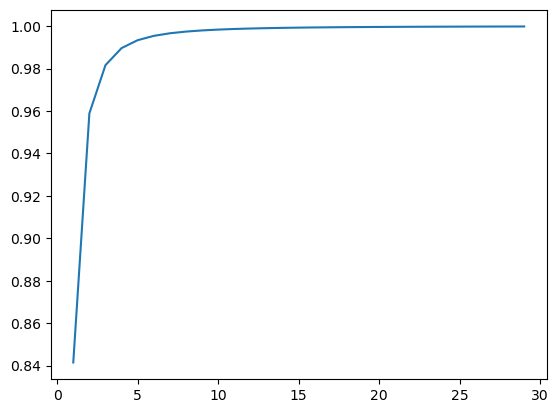

In [12]:
def compute():
    n_max = 30
    n_values = list(range(1,n_max))
    results = []

    for n in n_values:
        value = n * math.sin(1/n)
        results.append(value)
    
    plt.plot(n_values, results)
    plt.show()
compute()

![2.9](./assets/2.9.png)

## Problems, Section 4
For the following series, write formulas for the sequences $a_n$ , $S_n$ , and $R_n$ , and find the
limits of the sequences as $n \to \infty$ (if the limits exist).

### 4.1
$$\sum_{1}^{\infty} \frac{1}{2^n}$$

![4.1](./assets/4.1.png)

### 4.2
$$\sum_{0}^{\infty} \frac{1}{5^n}$$

![4.2](./assets/4.2.png)

### 4.3 
$$1-\frac{1}{2} + \frac{1}{4} - \frac{1}{8} + \frac{1}{16} \cdots$$


![4.3](./assets/4.3.png)

### 4.4
$$\sum_{1}^{\infty} e^{-n \ln 3}$$

![4.4](./assets/4.4.png)

### 4.5
$$
    \sum_{0}^{\infty} e^{2n \ln \sin \left ( \frac{\pi}{3} \right ) }
$$

![4.5](./assets/4.5.png)

### 4.6 
$$
    \sum_{1}^{\infty} \frac{1}{n(n + 1)}
$$

![4.6](./assets/4.6.png)

### 4.7
$$
    \frac{3}{1 \cdot 2} - \frac{5}{2 \cdot 3} + \frac{7}{3 \cdot 4} - \frac{9}{4 \cdot 5} + \cdots
$$

![4.7](./assets/4.7.png)